# Lead Scoring Pipeline — Fixed + Upgraded
### Shikhar Uniyal · Scowtt Internship Proof-of-Concept

**Fix log (15 bugs corrected):**
| # | Bug | Fix |
|---|-----|-----|
| 1 | `import torch` unused | Removed |
| 2 | `df.dropna()` wiped ~60% of rows | Replaced with median/mode imputation |
| 3 | `prospect_id` intent ambiguous | Clarified with comment |
| 4 | `StandardScaler sds` dead code | Removed, comment added |
| 5 | `pd.crosstab(X.columns,...)` nonsense line | Removed |
| 6 | Heatmap missing `plt.title()` / `plt.show()` | Added |
| 7 | `train_test_split` missing `stratify=y` | Added |
| 8 | `fit` + `transform` separately on train | Changed to `fit_transform` |
| 9 | `use_label_encoder=False` deprecated XGBoost param | Removed |
| 10 | `results` DataFrame index mismatch → NaN column | Fixed with `.values` alignment |
| 11 | `top_features` hardcoded transformer prefix strings | Derived programmatically |
| 12 | `final_sales_list` fragile index alignment | Rebuilt with explicit merge |
| 13 | Orphan `plt.figure()` before SHAP plots | Removed |
| 14 | `X_` binary mapping block — dead code | Removed (col_trans handles it) |
| 15 | EDA section placed after encoding setup | Reordered correctly |


## 1 · Imports & Data Load

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"archive/Leads X Education.csv")

print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (9240, 37)


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [2]:
df.dtypes

Prospect ID                                       object
Lead Number                                        int64
Lead Origin                                       object
Lead Source                                       object
Do Not Email                                      object
Do Not Call                                       object
Converted                                          int64
TotalVisits                                      float64
Total Time Spent on Website                        int64
Page Views Per Visit                             float64
Last Activity                                     object
Country                                           object
Specialization                                    object
How did you hear about X Education                object
What is your current occupation                   object
What matters most to you in choosing a course     object
Search                                            object
Magazine                       

## 2 · Schema Cleaning

In [3]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
      .str.replace("-", "_", regex=False)
)

In [4]:



df['city'] = df['city'].replace('Select', np.nan)  #replacesentinel strings
df['what_matters_most_to_you_in_choosing_a_course'] = (df['what_matters_most_to_you_in_choosing_a_course'].replace('NaN', np.nan))


# Dropping on crit cols - lead_source res modelling & prospect_id - linking results
df.dropna(subset=['lead_source', 'prospect_id'], inplace=True)

# --- Step 3: impute remaining nulls instead of dropping rows ---
# Numeric: median (robust to skew and outliers)
num_candidates = df.select_dtypes(include=[np.number]).columns
#rather than dropping the nulls filled with median
for col in num_candidates:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical: mode (most frequent value), fallback to 'Unknown'
cat_candidates = df.select_dtypes(include=['object']).columns
for col in cat_candidates:
    mode_val = df[col].mode()
    fill_val = mode_val[0] if len(mode_val) > 0 else 'Unknown'
    df[col].fillna(fill_val, inplace=True)

print(f"Shape after smart cleaning: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

Shape after smart cleaning: (9204, 37)
Remaining nulls: 0


In [5]:
df.columns

Index(['prospect_id', 'lead_number', 'lead_origin', 'lead_source',
       'do_not_email', 'do_not_call', 'converted', 'totalvisits',
       'total_time_spent_on_website', 'page_views_per_visit', 'last_activity',
       'country', 'specialization', 'how_did_you_hear_about_x_education',
       'what_is_your_current_occupation',
       'what_matters_most_to_you_in_choosing_a_course', 'search', 'magazine',
       'newspaper_article', 'x_education_forums', 'newspaper',
       'digital_advertisement', 'through_recommendations',
       'receive_more_updates_about_our_courses', 'tags', 'lead_quality',
       'update_me_on_supply_chain_content', 'get_updates_on_dm_content',
       'lead_profile', 'city', 'asymmetrique_activity_index',
       'asymmetrique_profile_index', 'asymmetrique_activity_score',
       'asymmetrique_profile_score',
       'i_agree_to_pay_the_amount_through_cheque',
       'a_free_copy_of_mastering_the_interview', 'last_notable_activity'],
      dtype='object')

## 3 · Target Isolation & Feature Drop

In [6]:
cols_to_drop = [
    'prospect_id', 'lead_number', 'converted', # IDs and Target
    'tags', 'lead_quality', 'lead_profile',    # Data Leakage
    'asymmetrique_activity_index', 'asymmetrique_profile_index',
    'asymmetrique_activity_score', 'asymmetrique_profile_score', # Legacy
    'magazine', 'receive_more_updates_about_our_courses',
    'update_me_on_supply_chain_content', 'get_updates_on_dm_content',
    'i_agree_to_pay_the_amount_through_cheque',  # Zero Variance
    'search', 'newspaper', 'x_education_forums',
    'newspaper_article', 'digital_advertisement',
    'through_recommendations','how_did_you_hear_about_x_education'
]

# BUG 3 NOTE: 'prospect_id' stays in df (not X) intentionally —
# we need it later to build the results table via df.loc[y_test.index]
X = df.drop(columns=cols_to_drop)
y = df['converted']
print(f"X shape: {X.shape}  |  y shape: {y.shape}")
X

X shape: (9204, 15)  |  y shape: (9204,)


,lead_origin,lead_source,do_not_email,do_not_call,totalvisits,total_time_spent_on_website,page_views_per_visit,last_activity,country,specialization,what_is_your_current_occupation,what_matters_most_to_you_in_choosing_a_course,city,a_free_copy_of_mastering_the_interview,last_notable_activity
0,API,Olark Chat,No,No,0.0,0,0.00,Page Visited on Website,India,Select,Unemployed,Better Career Prospects,Mumbai,No,Modified
1,API,Organic Search,No,No,5.0,674,2.50,Email Opened,India,Select,Unemployed,Better Career Prospects,Mumbai,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,No,2.0,1532,2.00,Email Opened,India,Business Administration,Student,Better Career Prospects,Mumbai,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,No,1.0,305,1.00,Unreachable,India,Media and Advertising,Unemployed,Better Career Prospects,Mumbai,No,Modified
4,Landing Page Submission,Google,No,No,2.0,1428,1.00,Converted to Lead,India,Select,Unemployed,Better Career Prospects,Mumbai,No,Modified
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9235,Landing Page Submission,Direct Traffic,Yes,No,8.0,1845,2.67,Email Marked Spam,Saudi Arabia,IT Projects Management,Unemployed,Better Career Prospects,Mumbai,No,Email Marked Spam
9236,Landing Page Submission,Direct Traffic,No,No,2.0,238,2.00,SMS Sent,India,Media and Advertising,Unemployed,Better Career Prospects,Mumbai,Yes,SMS Sent
9237,Landing Page Submission,Direct Traffic,Yes,No,2.0,199,2.00,SMS Sent,India,Business Administration,Unemployed,Better Career Prospects,Mumbai,Yes,SMS Sent
9238,Landing Page Submission,Google,No,No,3.0,499,3.00,SMS Sent,India,Human Resource Management,Unemployed,Better Career Prospects,Other Metro Cities,No,SMS Sent


In [7]:
# Quick null + unique value audit on the feature matrix
nan_cnt = X.isna().sum()
print(f"Nulls per column:\n{nan_cnt[nan_cnt > 0] if nan_cnt.sum() > 0 else 'None — clean.'}")
print()
print("Unique values per column:")
for col in X.columns:
    print(f"{col}:\t{X[col].nunique()} ")

Nulls per column:
None — clean.

Unique values per column:
lead_origin:	4 
lead_source:	21 
do_not_email:	2 
do_not_call:	2 
totalvisits:	41 
total_time_spent_on_website:	1730 
page_views_per_visit:	114 
last_activity:	17 
country:	38 
specialization:	19 
what_is_your_current_occupation:	6 
what_matters_most_to_you_in_choosing_a_course:	3 
city:	6 
a_free_copy_of_mastering_the_interview:	2 
last_notable_activity:	16 


In [8]:
y

0       0
1       0
2       1
3       0
4       1
       ..
9235    1
9236    0
9237    0
9238    1
9239    1
Name: converted, Length: 9204, dtype: int64

In [9]:
y.dtype

dtype('int64')

In [10]:
X.shape

(9204, 15)

In [11]:
X.dtypes

lead_origin                                       object
lead_source                                       object
do_not_email                                      object
do_not_call                                       object
totalvisits                                      float64
total_time_spent_on_website                        int64
page_views_per_visit                             float64
last_activity                                     object
country                                           object
specialization                                    object
what_is_your_current_occupation                   object
what_matters_most_to_you_in_choosing_a_course     object
city                                              object
a_free_copy_of_mastering_the_interview            object
last_notable_activity                             object
dtype: object

In [12]:
# cleanup done

## 4 · Column Typing

In [13]:

#  wncoding for col_trans is after EDA

cat_cols = X.select_dtypes(include=["object", "category"])

bin_cols = [col for col in cat_cols.columns if X[col].nunique() == 2]
print(f"Binary columns    ({len(bin_cols)}): {bin_cols}")
cat_cols_list = [col for col in cat_cols.columns if col not in bin_cols]
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns ({len(num_cols)}): {num_cols}")


print(f"Categorical cols  ({len(cat_cols_list)}): {cat_cols_list}")

Binary columns    (3): ['do_not_email', 'do_not_call', 'a_free_copy_of_mastering_the_interview']
Numerical columns (3): ['totalvisits', 'total_time_spent_on_website', 'page_views_per_visit']
Categorical cols  (9): ['lead_origin', 'lead_source', 'last_activity', 'country', 'specialization', 'what_is_your_current_occupation', 'what_matters_most_to_you_in_choosing_a_course', 'city', 'last_notable_activity']


## 5 · EDA — Inspect Raw Data Before Any Encoding

basic corr on numerical data here

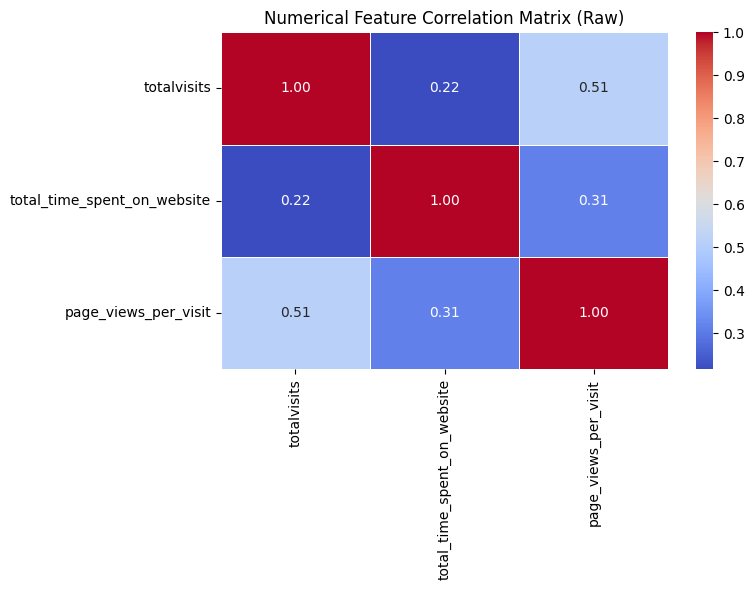

In [14]:
corr_mat = X[num_cols].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Numerical Feature Correlation Matrix (Raw)')
plt.tight_layout()
plt.savefig("assets/plot1.png", dpi=300, bbox_inches="tight")
plt.show()


class imbalance check here

Class distribution:
converted
0    5672
1    3532
Name: count, dtype: int64


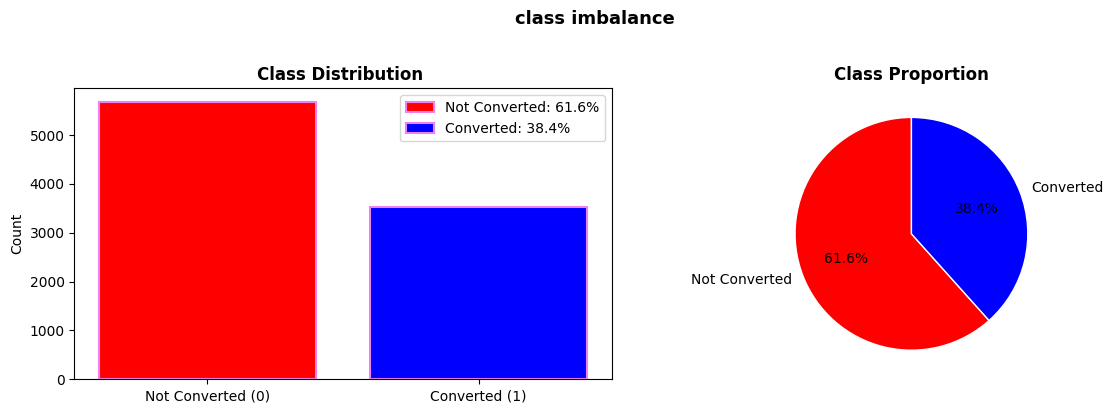

Imbalance ratio: 1.61:1 
scale_pos_weight = 1.61


In [15]:
#  Deep EDA SEction
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Class balance in converted
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = y.value_counts()
print(f"Class distribution:\n{counts}")
bars = axes[0].bar(['Not Converted (0)', 'Converted (1)'], counts.values, color=["red", "blue"], edgecolor='violet', linewidth=1.5)
axes[0].set_title('Class Distribution ', fontweight='bold')
axes[0].set_ylabel('Count')
not_conv_pct = counts[0] / len(y) * 100
conv_pct = counts[1] / len(y) * 100

axes[0].legend(bars,[
    f'Not Converted: {not_conv_pct:.1f}%',
    f'Converted: {conv_pct:.1f}%'
])

axes[1].pie(counts.values, labels=['Not Converted', 'Converted'],
            colors=['red', 'blue'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.suptitle('class imbalance', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig("assets/plot2.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Imbalance ratio: {counts[0]/counts[1]:.2f}:1 \nscale_pos_weight = {counts[0]/counts[1]:.2f}")


Distribution of the numeric data

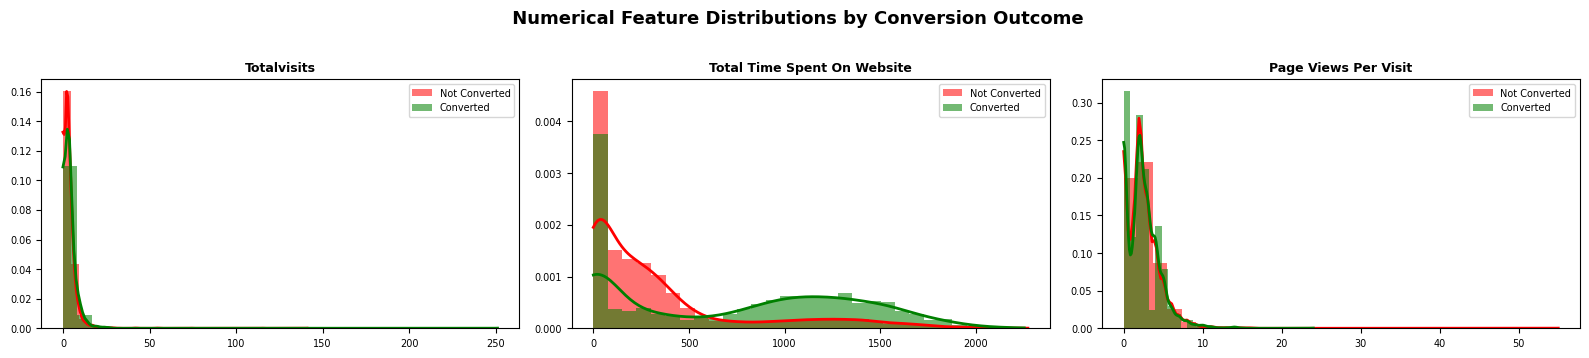

In [16]:
# Numerical feature distributions split by target
num_cols_raw = X.select_dtypes(include=[np.number]).columns.tolist()
X_plot = X.copy()
X_plot['converted'] = y.values

n = len(num_cols_raw)
ncols = 3  #fixed per row
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols_raw):
    ax = axes[i]
    for label, color, name in [(0, 'red', 'Not Converted'), (1, 'green', 'Converted')]:
        subset = X_plot[X_plot['converted'] == label][col].dropna()
        ax.hist(subset, bins=30, alpha=0.55, color=color, label=name, density=True)
        # KDE overlay
        if len(subset) > 10:
            kde_x = np.linspace(subset.min(), subset.max(), 200)
            kde = stats.gaussian_kde(subset)
            ax.plot(kde_x, kde(kde_x), color=color, linewidth=2)
    ax.set_title(col.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(' Numerical Feature Distributions by Conversion Outcome', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

plt.savefig("assets/plot3.png", dpi=300, bbox_inches="tight")
plt.show()


In [17]:
# Outlier detection via IQR + Z-score
print("=" * 60)
print("OUTLIER AUDIT")
print("=" * 60)

outlier_report = []
for col in num_cols_raw:
    series = X[col].dropna()
    
    # IQR method
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()
    
    # Z-score method (|z| > 3)
    z_outliers = (np.abs(stats.zscore(series)) > 3).sum()
    
    # Skewness
    skew = series.skew()
    
    outlier_report.append({
        'feature': col,
        'iqr_outliers': iqr_outliers,
        'iqr_pct': round(iqr_outliers / len(series) * 100, 1),
        'z_outliers': z_outliers,
        'skewness': round(skew, 3),
        'skew_severity': 'HIGH' if abs(skew) > 1 else ('MODERATE' if abs(skew) > 0.5 else 'LOW')
    })

outlier_df = pd.DataFrame(outlier_report).sort_values('iqr_outliers', ascending=False)
print(outlier_df.to_string(index=False))
print()
print("→ Features with HIGH skewness justify your PowerTransformer (Yeo-Johnson) choice.")


OUTLIER AUDIT
                    feature  iqr_outliers  iqr_pct  z_outliers  skewness skew_severity
       page_views_per_visit           360      3.9         120     2.903          HIGH
                totalvisits           267      2.9          83    20.063          HIGH
total_time_spent_on_website             0      0.0           7     0.952      MODERATE

→ Features with HIGH skewness justify your PowerTransformer (Yeo-Johnson) choice.


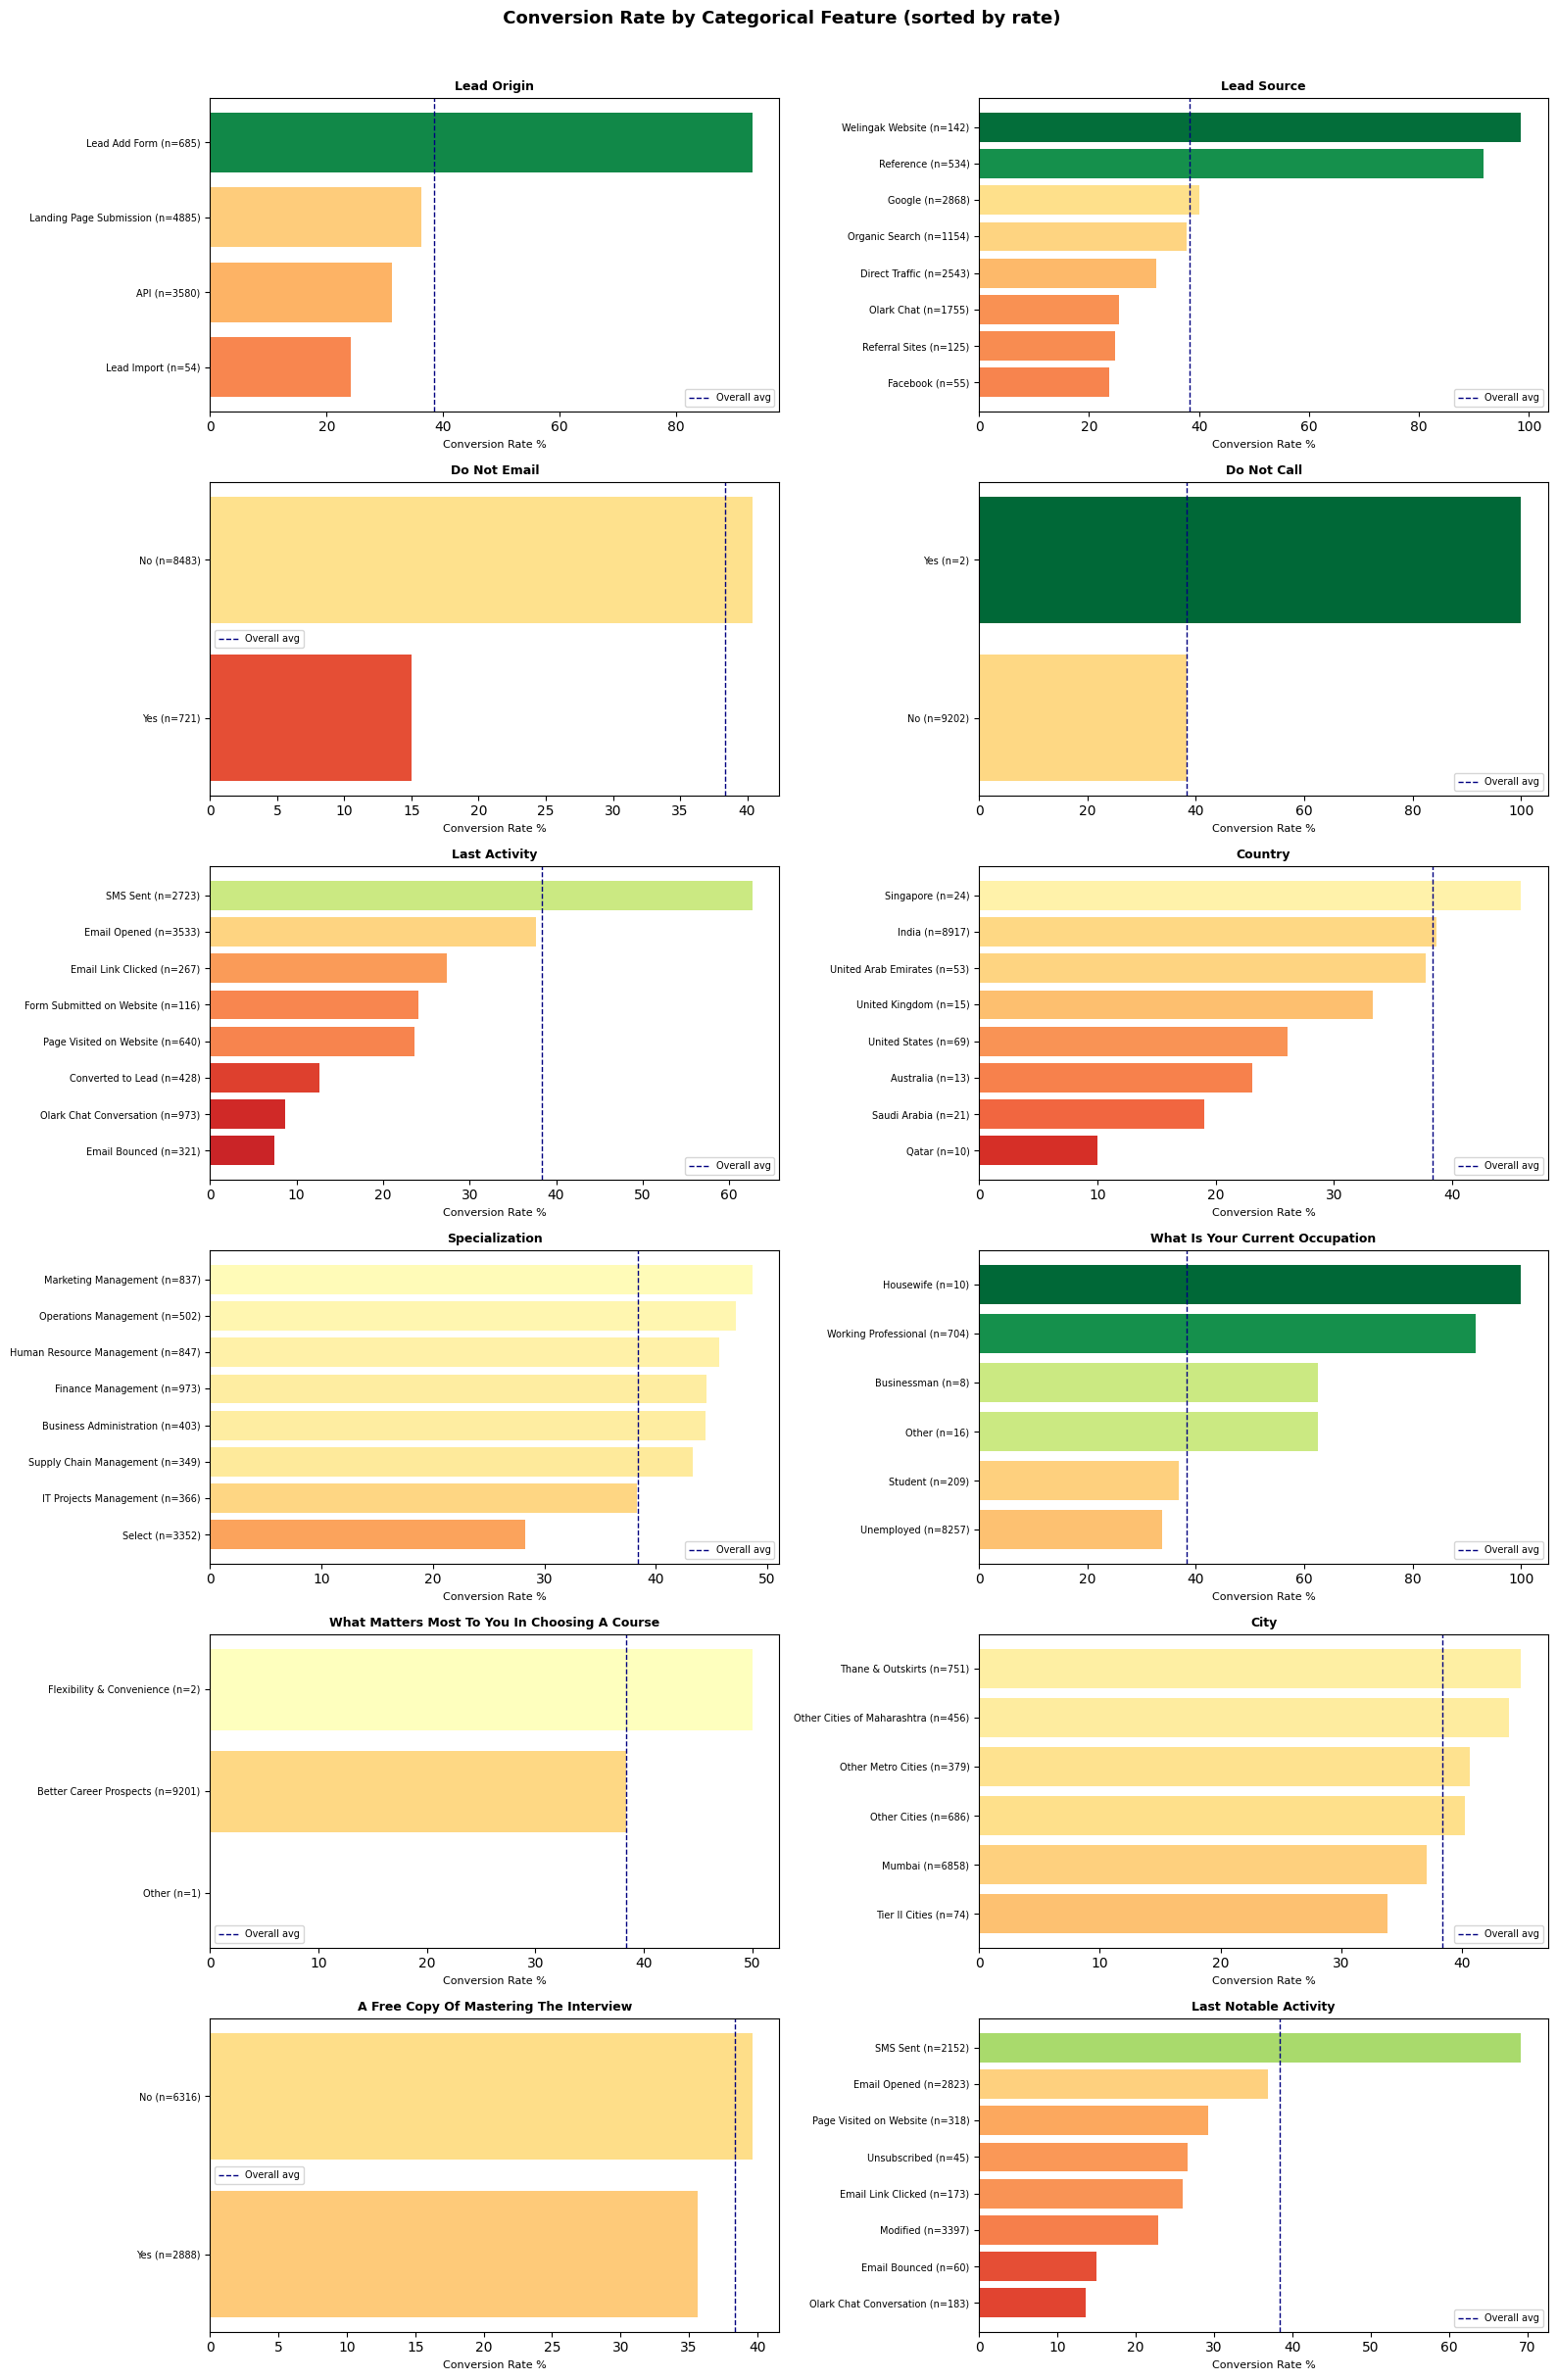

In [18]:
#  Categorical feature vs target (conversion rate per category)
cat_cols_raw = X.select_dtypes(include=['object']).columns.tolist()
X_plot = X.copy()
X_plot['converted'] = y.values

# Pick top-N categories by frequency for readability
TOP_N = 8

fig_rows = (len(cat_cols_raw) + 1) // 2
fig, axes = plt.subplots(fig_rows, 2, figsize=(16, fig_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols_raw):
    ax = axes[i]
    conv_rate = (X_plot.groupby(col)['converted']
                       .agg(['mean', 'count'])
                       .rename(columns={'mean': 'conv_rate', 'count': 'n'})
                       .sort_values('n', ascending=False)
                       .head(TOP_N))
    conv_rate = conv_rate.sort_values('conv_rate', ascending=True)
    
    bars = ax.barh(range(len(conv_rate)), conv_rate['conv_rate'] * 100,
                   color=plt.cm.RdYlGn(conv_rate['conv_rate'].values))
    ax.set_yticks(range(len(conv_rate)))
    ax.set_yticklabels([f"{idx} (n={conv_rate.loc[idx,'n']})" 
                        for idx in conv_rate.index], fontsize=7)
    ax.set_xlabel('Conversion Rate %', fontsize=8)
    ax.set_title(col.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    ax.axvline(y.mean() * 100, color='navy', linestyle='--', linewidth=1, label='Overall avg')
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(' Conversion Rate by Categorical Feature (sorted by rate)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

plt.savefig("assets/plot4.png", dpi=300, bbox_inches="tight")
plt.show()


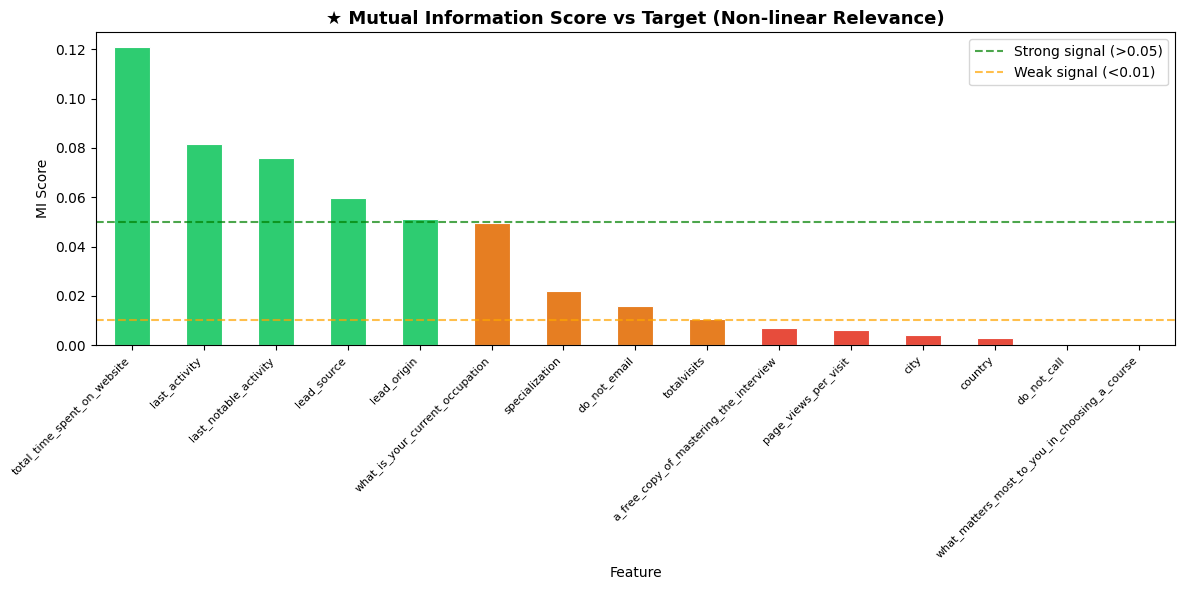


Top 10 features by Mutual Information:
total_time_spent_on_website               0.120887
last_activity                             0.081593
last_notable_activity                     0.075876
lead_source                               0.059535
lead_origin                               0.051353
what_is_your_current_occupation           0.049614
specialization                            0.021854
do_not_email                              0.015803
totalvisits                               0.010499
a_free_copy_of_mastering_the_interview    0.007143

→ Features below 0.01 MI are likely noise. Consider dropping them.


In [19]:
# Mutual Information (non-linear feature relevance vs target)
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

X_mi = X.copy()
for col in X_mi.select_dtypes(include='object').columns:
    X_mi[col] = LabelEncoder().fit_transform(X_mi[col].astype(str))
X_mi = X_mi.fillna(X_mi.median())

mi_scores = mutual_info_classif(X_mi, y, random_state=42, n_neighbors=5)
mi_series = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['#2ecc71' if v > 0.05 else '#e67e22' if v > 0.01 else '#e74c3c' 
          for v in mi_series.values]
mi_series.plot(kind='bar', color=colors, edgecolor='white', linewidth=0.8)
plt.title('★ Mutual Information Score vs Target (Non-linear Relevance)', 
          fontsize=13, fontweight='bold')
plt.ylabel('MI Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.axhline(0.05, color='green', linestyle='--', alpha=0.7, label='Strong signal (>0.05)')
plt.axhline(0.01, color='orange', linestyle='--', alpha=0.7, label='Weak signal (<0.01)')
plt.legend()
plt.tight_layout()

plt.savefig("assets/plot5.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nTop 10 features by Mutual Information:")
print(mi_series.head(10).to_string())
print("\n→ Features below 0.01 MI are likely noise. Consider dropping them.")


In [20]:
# Churn correlation (your original analysis — kept intact)
df['is_churn'] = 1 - df['converted']
churn_corr = df[num_cols + ['is_churn']].corr()['is_churn'].sort_values(ascending=False)
print("Top Numerical Drivers of Churn (Exit Signals):")
print(churn_corr)

Top Numerical Drivers of Churn (Exit Signals):
is_churn                       1.000000
page_views_per_visit           0.001558
totalvisits                   -0.031540
total_time_spent_on_website   -0.366428
Name: is_churn, dtype: float64


## 6 · Encoding & Preprocessing Setup

In [21]:
# ★ ADDED — Cardinality and variance audit before encoding
print("=" * 60)
print("CARDINALITY  Categorical Features")
print("=" * 60)
print(f"{'Feature':<50} {'Unique':>8}  {'OHE columns (capped at 10)':>26}")
print("-" * 90)
for col in cat_cols_list:
    n_unique = X[col].nunique()
    ohe_cols = min(n_unique, 10)  # your max_categories=10
    flag = " HIGH" if n_unique > 15 else ""
    print(f"{col:<50} {n_unique:>8}  {ohe_cols:>26}{flag}")

print()
print("=" * 60)
print("★ NEAR-ZERO VARIANCE AUDIT — Numerical Features")
print("=" * 60)
for col in num_cols:
    cv = X[col].std() / (X[col].mean() + 1e-9)  # Coefficient of variation
    flag = " ⚠ LOW VARIANCE" if cv < 0.01 else ""
    print(f"{col:<45}  CV={cv:.4f}{flag}")


CARDINALITY  Categorical Features
Feature                                              Unique  OHE columns (capped at 10)
------------------------------------------------------------------------------------------
lead_origin                                               4                           4
lead_source                                              21                          10 HIGH
last_activity                                            17                          10 HIGH
country                                                  38                          10 HIGH
specialization                                           19                          10 HIGH
what_is_your_current_occupation                           6                           6
what_matters_most_to_you_in_choosing_a_course             3                           3
city                                                      6                           6
last_notable_activity                                    16    

In [22]:
# Skewness correction via Yeo-Johnson (handles negatives, unlike Box-Cox)
from sklearn.preprocessing import PowerTransformer
pwt = PowerTransformer(method="yeo-johnson", standardize=True, copy=True)

In [23]:
# One-hot encoding for multi-class categoricals
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(
    handle_unknown='ignore',  # Don't crash on unseen categories at inference
    sparse_output=False,      # Return dense array (readable + compatible)
    max_categories=10         # Cap cardinality to prevent feature explosion
)

In [24]:
# BUG 4 FIXED: StandardScaler (sds) was defined but never added to col_trans.
# PowerTransformer(standardize=True) already handles both skew correction
# AND standardisation in one step — sds was redundant dead code. Removed.
# If you want a separate scaler for a future pipeline branch, add it then.

In [25]:
# Binary encoder: drop='first' gives one column per binary feature (0/1)
bhe = OneHotEncoder(
    handle_unknown='ignore',
    drop='first',        # Yes/No → single 0/1 column, no multicollinearity
    sparse_output=False
)

In [26]:
from sklearn.compose import ColumnTransformer

col_trans = ColumnTransformer(
    transformers=[
        ('category',      ohe, cat_cols_list),
        ('numerical_skew', pwt, num_cols),
        ('bin_col',        bhe, bin_cols),
    ],
    remainder='passthrough',  # Pass through any cols not listed above
    sparse_threshold=0.3,
    n_jobs=-1,
    verbose=True,             # Prints time per transformer — useful for profiling
    verbose_feature_names_out=True
)
# Design note: col_trans is defined here but NOT fitted yet.
# Fitting happens AFTER train/test split to prevent data leakage.

In [27]:


for cols in bin_cols:
    X[cols] = X[cols].apply(lambda x: 1 if x == "Yes" else 0)
X

,lead_origin,lead_source,do_not_email,do_not_call,totalvisits,total_time_spent_on_website,page_views_per_visit,last_activity,country,specialization,what_is_your_current_occupation,what_matters_most_to_you_in_choosing_a_course,city,a_free_copy_of_mastering_the_interview,last_notable_activity
0,API,Olark Chat,0,0,0.0,0,0.00,Page Visited on Website,India,Select,Unemployed,Better Career Prospects,Mumbai,0,Modified
1,API,Organic Search,0,0,5.0,674,2.50,Email Opened,India,Select,Unemployed,Better Career Prospects,Mumbai,0,Email Opened
2,Landing Page Submission,Direct Traffic,0,0,2.0,1532,2.00,Email Opened,India,Business Administration,Student,Better Career Prospects,Mumbai,1,Email Opened
3,Landing Page Submission,Direct Traffic,0,0,1.0,305,1.00,Unreachable,India,Media and Advertising,Unemployed,Better Career Prospects,Mumbai,0,Modified
4,Landing Page Submission,Google,0,0,2.0,1428,1.00,Converted to Lead,India,Select,Unemployed,Better Career Prospects,Mumbai,0,Modified
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9235,Landing Page Submission,Direct Traffic,1,0,8.0,1845,2.67,Email Marked Spam,Saudi Arabia,IT Projects Management,Unemployed,Better Career Prospects,Mumbai,0,Email Marked Spam
9236,Landing Page Submission,Direct Traffic,0,0,2.0,238,2.00,SMS Sent,India,Media and Advertising,Unemployed,Better Career Prospects,Mumbai,1,SMS Sent
9237,Landing Page Submission,Direct Traffic,1,0,2.0,199,2.00,SMS Sent,India,Business Administration,Unemployed,Better Career Prospects,Mumbai,1,SMS Sent
9238,Landing Page Submission,Google,0,0,3.0,499,3.00,SMS Sent,India,Human Resource Management,Unemployed,Better Career Prospects,Other Metro Cities,0,SMS Sent


## 7 · Train / Test Split

In [28]:
# BUG 7 FIXED: added stratify=y
# Without it, on a 38/62 imbalanced dataset, the random split can produce
# a test set with a very different class ratio — making metrics unreliable.
# stratify=y guarantees both splits mirror the original class distribution.

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ← FIXED
)

print(f"x_train: {x_train.shape}  |  y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape}   |  y_test:  {y_test.shape}")
print()
print(f"Train conversion rate: {y_train.mean():.3f}")
print(f"Test  conversion rate: {y_test.mean():.3f}  ← should match train")

x_train: (7363, 15)  |  y_train: (7363,)
x_test:  (1841, 15)   |  y_test:  (1841,)

Train conversion rate: 0.384
Test  conversion rate: 0.383  ← should match train


In [29]:
x_test.dtypes

lead_origin                                       object
lead_source                                       object
do_not_email                                       int64
do_not_call                                        int64
totalvisits                                      float64
total_time_spent_on_website                        int64
page_views_per_visit                             float64
last_activity                                     object
country                                           object
specialization                                    object
what_is_your_current_occupation                   object
what_matters_most_to_you_in_choosing_a_course     object
city                                              object
a_free_copy_of_mastering_the_interview             int64
last_notable_activity                             object
dtype: object

In [30]:
x_test

,lead_origin,lead_source,do_not_email,do_not_call,totalvisits,total_time_spent_on_website,page_views_per_visit,last_activity,country,specialization,what_is_your_current_occupation,what_matters_most_to_you_in_choosing_a_course,city,a_free_copy_of_mastering_the_interview,last_notable_activity
3219,API,Google,0,0,3.0,1324,1.50,Email Opened,India,Select,Unemployed,Better Career Prospects,Mumbai,0,Email Opened
5075,Landing Page Submission,Direct Traffic,0,0,2.0,1380,2.00,SMS Sent,India,Business Administration,Unemployed,Better Career Prospects,Mumbai,1,SMS Sent
570,Landing Page Submission,Google,0,0,5.0,409,5.00,Email Opened,India,IT Projects Management,Unemployed,Better Career Prospects,Mumbai,0,Email Opened
4973,API,Organic Search,0,0,3.0,951,1.50,SMS Sent,India,Retail Management,Unemployed,Better Career Prospects,Mumbai,0,Modified
2387,Landing Page Submission,Direct Traffic,0,0,11.0,985,1.83,Email Opened,India,Human Resource Management,Unemployed,Better Career Prospects,Thane & Outskirts,1,Email Opened
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2474,API,Olark Chat,0,0,0.0,0,0.00,Email Opened,India,Select,Unemployed,Better Career Prospects,Mumbai,0,Modified
7841,Landing Page Submission,Google,0,0,2.0,702,2.00,Email Opened,India,Marketing Management,Unemployed,Better Career Prospects,Other Cities of Maharashtra,0,Email Opened
4915,Landing Page Submission,Direct Traffic,0,0,2.0,47,2.00,Email Opened,India,Operations Management,Unemployed,Better Career Prospects,Mumbai,1,Email Opened
4762,Landing Page Submission,Direct Traffic,0,0,7.0,32,7.00,Email Opened,India,Hospitality Management,Student,Better Career Prospects,Mumbai,1,Email Opened


In [31]:
# BUG 8 FIXED: replaced fit() + transform(x_train) with fit_transform(x_train)
# fit() then transform() on the same data is correct but redundant —
# fit_transform() does both in one pass (more efficient for PowerTransformer).
# x_test uses transform() only — correct, never fit on test data.

col_trans.fit(x_train)               # Learn stats from training data only
X_Train = col_trans.fit_transform(x_train)  # BUG 8 FIXED
X_Test  = col_trans.transform(x_test)       # Apply learned stats to test

print(f"X_Train shape: {X_Train.shape}")
print(f"X_Test  shape: {X_Test.shape}")

X_Train shape: (7363, 75)
X_Test  shape: (1841, 75)


In [32]:
X_Test

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(1841, 75))

In [33]:
X_Train

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 1.],
       ...,
       [0., 1., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(7363, 75))

In [34]:
y_train.shape

(7363,)

In [35]:
counter = y_train.value_counts()
print(counter)
imbalance_weight = counter[0] / counter[1]
print(f"\nscale_pos_weight = {imbalance_weight:.4f}")
print("(negatives / positives — tells XGBoost to penalise missing positives more)")

converted
0    4537
1    2826
Name: count, dtype: int64

scale_pos_weight = 1.6054
(negatives / positives — tells XGBoost to penalise missing positives more)


# PRE MODEL CHECKS SMOTE + BASELINE

In [36]:
# ★ ADDED — Dummy baseline + class distribution post-split check

from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_Train, y_train)
dummy_pred = dummy.predict_proba(X_Test)[:, 1]
dummy_auc = roc_auc_score(y_test, dummy_pred)

print("=" * 50)
print("★ BASELINE (Most-Frequent Classifier)")
print("=" * 50)
print(f"Dummy AUC-ROC : {dummy_auc:.4f}  (expected ~0.5)")
print()
print("Train class distribution:")
print((y_train.value_counts() / len(y_train)).round(3).to_string())
print()
print("Test class distribution:")
print((y_test.value_counts() / len(y_test)).round(3).to_string())
print()
print("→ Stratified split confirmed — class ratio preserved.")


★ BASELINE (Most-Frequent Classifier)
Dummy AUC-ROC : 0.5000  (expected ~0.5)

Train class distribution:
converted
0    0.616
1    0.384

Test class distribution:
converted
0    0.617
1    0.383

→ Stratified split confirmed — class ratio preserved.


In [37]:
# ★ ADDED — Check whether SMOTE actually helps on this dataset
# For XGBoost + scale_pos_weight, SMOTE rarely helps — let's verify

try:
    from imblearn.over_sampling import SMOTE
    
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_Train_sm, y_Train_sm = smote.fit_resample(X_Train, y_train)
    
    print("=" * 50)
    print("★ SMOTE RESAMPLING ANALYSIS")
    print("=" * 50)
    print(f"Before SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"After  SMOTE: {dict(zip(*np.unique(y_Train_sm, return_counts=True)))}")
    print()
    print("→ We will train XGBoost with scale_pos_weight (NOT SMOTE).")
    print("  Reason: XGBoost's internal weighting avoids synthetic artefacts.")
    print("  SMOTE-augmented data is stored as X_Train_sm / y_Train_sm")
    print("  for ablation comparison in Section 11.")
    SMOTE_AVAILABLE = True
except ImportError:
    print("imbalanced-learn not installed — skipping SMOTE comparison.")
    SMOTE_AVAILABLE = False


★ SMOTE RESAMPLING ANALYSIS
Before SMOTE: {np.int64(0): np.int64(4537), np.int64(1): np.int64(2826)}
After  SMOTE: {np.int64(0): np.int64(4537), np.int64(1): np.int64(4537)}

→ We will train XGBoost with scale_pos_weight (NOT SMOTE).
  Reason: XGBoost's internal weighting avoids synthetic artefacts.
  SMOTE-augmented data is stored as X_Train_sm / y_Train_sm
  for ablation comparison in Section 11.


## 8 · XGBoost Training

In [38]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=imbalance_weight,  # Crucial for imbalanced lead data
    random_state=42,
    # BUG 9 FIXED: removed use_label_encoder=False
    # Deprecated since XGBoost 1.6 — raises a FutureWarning and clutters output.
    # It's now the default behaviour; the parameter no longer exists in 2.x.
    eval_metric='logloss'
)

model.fit(X_Train, y_train)
y_pred = model.predict(X_Test)
y_prob = model.predict_proba(X_Test)[:, 1]  # P(conversion) for each lead
print("Model trained successfully.")

Model trained successfully.


## 9 · Results Table

In [39]:
# BUG 10 FIXED: original code mixed y_test (original df index) with
# y_prob (numpy array, 0-indexed). Joining them created a NaN column for
# 'conversion_probability' because the indices didn't align.
# Fix: use y_test.values and y_pred (both numpy) alongside y_test.index
# to build a consistent DataFrame.

results = pd.DataFrame({
    'prospect_id':          df.loc[y_test.index, 'prospect_id'].values,  # FIXED
    'actual_conversion':    y_test.values,                                # FIXED
    'predicted_conversion': y_pred,                                       # already numpy
    'conversion_probability': y_prob                                      # already numpy
})

print(f"NaN check: {results.isnull().sum().to_dict()}")  # Should all be 0
results.head()

NaN check: {'prospect_id': 0, 'actual_conversion': 0, 'predicted_conversion': 0, 'conversion_probability': 0}


,prospect_id,actual_conversion,predicted_conversion,conversion_probability
0,923502de-6eb4-4912-a118-5cf44e1745fe,0,1,0.636706
1,c7b3f55a-5f66-4502-8c26-f613cb3bfaac,0,1,0.771869
2,6aed9d66-e7e2-4fc1-bf2b-2842205dab32,0,0,0.149883
3,1e0144e0-6a0e-4326-afe4-7fa28679ee09,1,1,0.801348
4,1fe36198-1960-41c5-8f78-cc10873632c4,1,1,0.804698


## 10 · Feature Importance

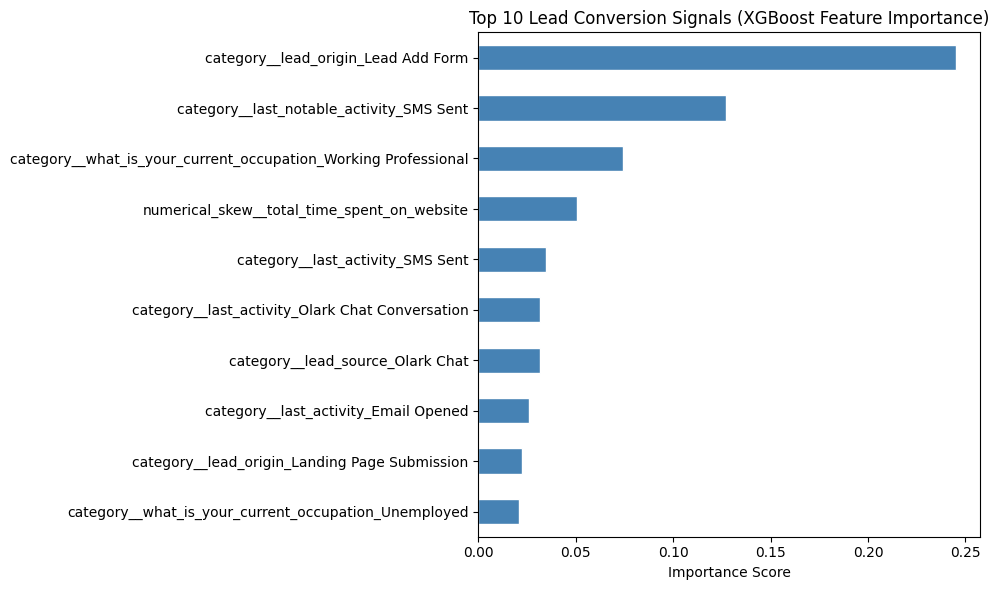

In [40]:
feature_names = col_trans.get_feature_names_out()

importances = model.feature_importances_
feat_importances = pd.Series(importances, index=feature_names)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 Lead Conversion Signals (XGBoost Feature Importance)')
plt.xlabel('Importance Score')
plt.tight_layout()

plt.savefig("assets/plot6.png", dpi=300, bbox_inches="tight")
plt.show()

★ CLASSIFICATION REPORT
               precision    recall  f1-score   support

Not Converted       0.89      0.84      0.86      1135
    Converted       0.76      0.83      0.79       706

     accuracy                           0.83      1841
    macro avg       0.82      0.83      0.83      1841
 weighted avg       0.84      0.83      0.83      1841

AUC-ROC      : 0.9046
Brier Score  : 0.1226  (lower=better, 0=perfect)
Log Loss     : 0.3912
Baseline AUC : 0.5000
Lift over baseline: +0.4046


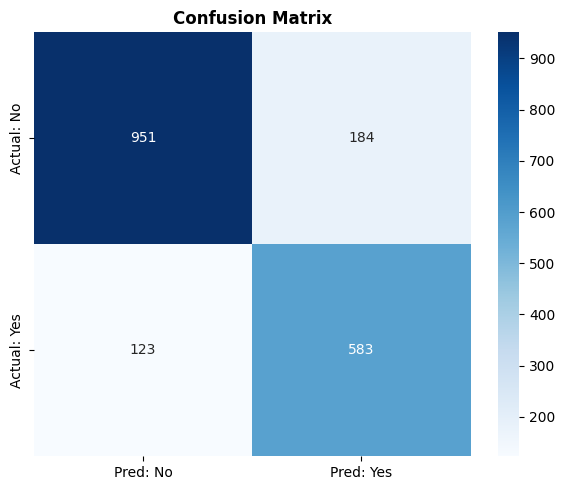


False Positive Rate : 0.162  (184 leads wrongly called Hot)
False Negative Rate : 0.174  (123 real converters missed)
→ For Scowtt: FPR wastes sales effort. FNR misses revenue. Tune threshold accordingly.


In [41]:
# ★ ADDED — 11.1 Classification Report + Confusion Matrix
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve,
                              precision_recall_curve, average_precision_score,
                              brier_score_loss, log_loss)
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("★ CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Not Converted', 'Converted']))

print(f"AUC-ROC      : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Brier Score  : {brier_score_loss(y_test, y_prob):.4f}  (lower=better, 0=perfect)")
print(f"Log Loss     : {log_loss(y_test, y_prob):.4f}")
print(f"Baseline AUC : {dummy_auc:.4f}")
print(f"Lift over baseline: +{roc_auc_score(y_test, y_prob) - dummy_auc:.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
ax.set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout()

plt.savefig("assets/plot7.png", dpi=300, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nFalse Positive Rate : {fp/(fp+tn):.3f}  ({fp} leads wrongly called Hot)")
print(f"False Negative Rate : {fn/(fn+tp):.3f}  ({fn} real converters missed)")
print("→ For Scowtt: FPR wastes sales effort. FNR misses revenue. Tune threshold accordingly.")


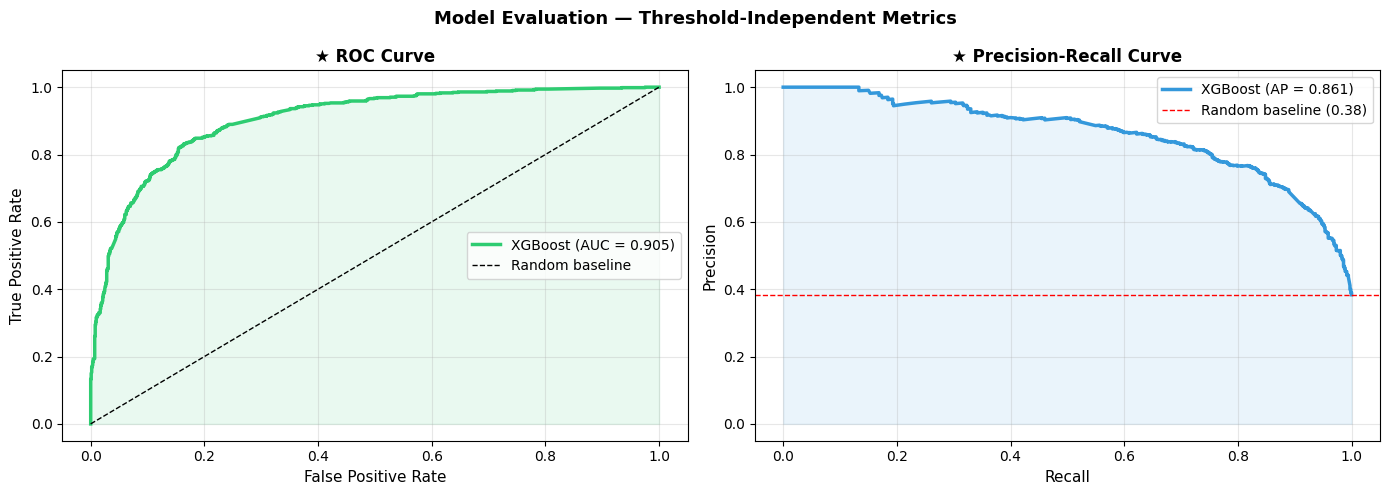

In [42]:
# ★ ADDED — 11.2 ROC Curve + Precision-Recall Curve side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#2ecc71', linewidth=2.5, label=f'XGBoost (AUC = {auc_score:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2ecc71')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('★ ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)
baseline_pr = y_test.mean()
axes[1].plot(recall, precision, color='#3498db', linewidth=2.5, 
             label=f'XGBoost (AP = {ap_score:.3f})')
axes[1].axhline(baseline_pr, color='red', linestyle='--', linewidth=1,
                label=f'Random baseline ({baseline_pr:.2f})')
axes[1].fill_between(recall, precision, alpha=0.1, color='#3498db')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('★ Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('Model Evaluation — Threshold-Independent Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig("assets/plot8.png", dpi=300, bbox_inches="tight")
plt.show()


e:\python_pi\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


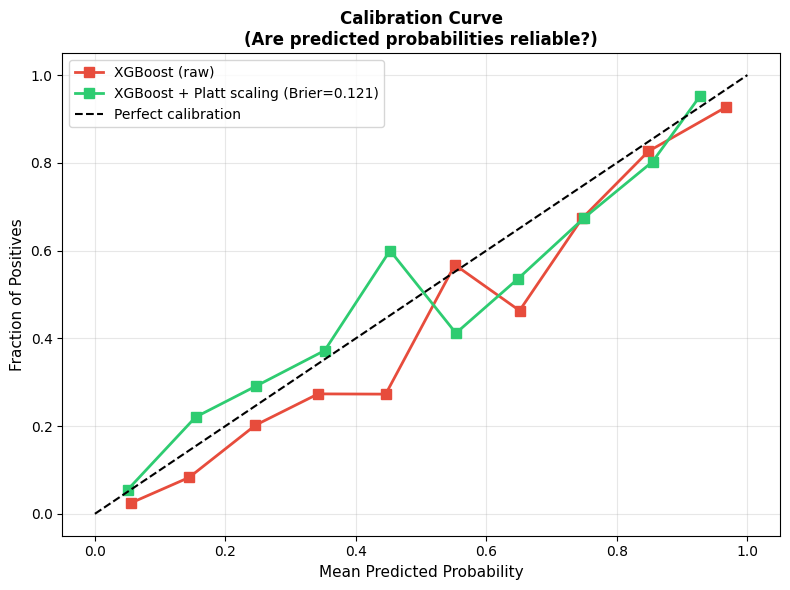

Raw XGBoost Brier Score      : 0.1226
Calibrated XGBoost Brier     : 0.1209
→ Use calibrated probabilities for your FastAPI endpoint (Stage 4).
  Raw XGB scores are not true probabilities — calibration fixes this.


In [43]:
# ★ ADDED — 11.3 Calibration Curve (is P(convert)=0.8 actually 80% likely?)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

fig, ax = plt.subplots(figsize=(8, 6))

# Raw XGBoost
fraction_of_positives, mean_predicted = calibration_curve(y_test, y_prob, n_bins=10)
ax.plot(mean_predicted, fraction_of_positives, 's-', color='#e74c3c', 
        linewidth=2, markersize=7, label='XGBoost (raw)')

# Platt-calibrated XGBoost
cal_model = CalibratedClassifierCV(model, method='sigmoid', cv='prefit')
cal_model.fit(X_Train, y_train)
y_prob_cal = cal_model.predict_proba(X_Test)[:, 1]
fop_cal, mpv_cal = calibration_curve(y_test, y_prob_cal, n_bins=10)
ax.plot(mpv_cal, fop_cal, 's-', color='#2ecc71', linewidth=2, markersize=7,
        label=f'XGBoost + Platt scaling (Brier={brier_score_loss(y_test, y_prob_cal):.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect calibration')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.05, color='black')
ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives', fontsize=11)
ax.set_title('Calibration Curve\n(Are predicted probabilities reliable?)', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("assets/plot9.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Raw XGBoost Brier Score      : {brier_score_loss(y_test, y_prob):.4f}")
print(f"Calibrated XGBoost Brier     : {brier_score_loss(y_test, y_prob_cal):.4f}")
print("→ Use calibrated probabilities for your FastAPI endpoint (Stage 4).")
print("  Raw XGB scores are not true probabilities — calibration fixes this.")


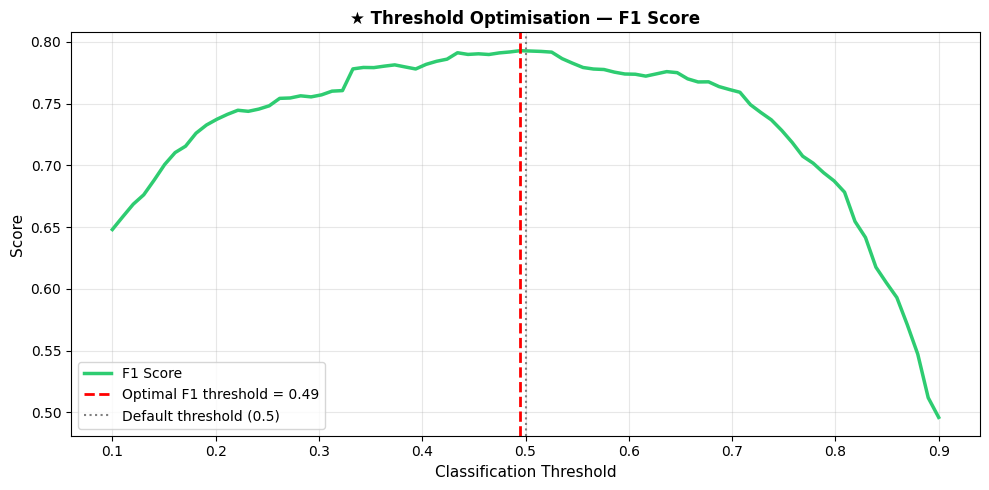

Default threshold (0.5) F1  : 0.7916
Optimal threshold (0.49) F1  : 0.7930

→ Use 0.49 as your Stage 5 webhook trigger threshold.


In [44]:
# ★ ADDED — 11.4 Threshold optimisation (F1, Precision, Recall vs threshold)
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 80)
f1s, precs, recs = [], [], []

for t in thresholds:
    preds_t = (y_prob >= t).astype(int)
    f1s.append(f1_score(y_test, preds_t, zero_division=0))
    precs.append(precision_recall_curve(y_test, y_prob)[0][
        np.argmin(np.abs(precision_recall_curve(y_test, y_prob)[2] - t))
    ])
    recs.append(f1_score(y_test, preds_t, zero_division=0, average='macro'))

best_t = thresholds[np.argmax(f1s)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1s, label='F1 Score', color='#2ecc71', linewidth=2.5)
ax.axvline(best_t, color='red', linestyle='--', linewidth=2,
           label=f'Optimal F1 threshold = {best_t:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Default threshold (0.5)')
ax.set_xlabel('Classification Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('★ Threshold Optimisation — F1 Score', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()


plt.savefig("assets/plot10.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Default threshold (0.5) F1  : {f1_score(y_test, (y_prob>=0.5).astype(int)):.4f}")
print(f"Optimal threshold ({best_t:.2f}) F1  : {f1_score(y_test, (y_prob>=best_t).astype(int)):.4f}")
print(f"\n→ Use {best_t:.2f} as your Stage 5 webhook trigger threshold.")
OPTIMAL_THRESHOLD = best_t


## 11 · Ranked Leads

In [45]:
ranked_leads = pd.DataFrame({
    'prospect_id':    df.loc[y_test.index, 'prospect_id'].values,
    'conversion_score': (y_prob * 100).round(2),
    'actual_converted': y_test.values
}).sort_values(by='conversion_score', ascending=False)

ranked_leads.head()

,prospect_id,conversion_score,actual_converted
585,74a7a568-2719-4e18-8c38-7827366eb107,99.779999,1
920,91e4fcd1-547f-45fd-9cd9-f679c1c27440,99.750000,1
996,99490730-2753-4e3f-9051-f982baa88bb5,99.699997,1
778,122d9e0e-01b9-4862-890e-094cd73f69f2,99.620003,1
1143,61314214-b313-40ff-b95e-ae5a7d079d3a,99.589996,1


In [46]:
def categorize_lead(score):
    if score >= 80: return 'HOT (Call Now)'
    if score >= 50: return 'WARM (Email Nurture)'
    return 'COLD (Ignore/Low Priority)'

ranked_leads['category'] = ranked_leads['conversion_score'].apply(categorize_lead)
print(ranked_leads.head(10))

                               prospect_id  conversion_score  \
585   74a7a568-2719-4e18-8c38-7827366eb107         99.779999   
920   91e4fcd1-547f-45fd-9cd9-f679c1c27440         99.750000   
996   99490730-2753-4e3f-9051-f982baa88bb5         99.699997   
778   122d9e0e-01b9-4862-890e-094cd73f69f2         99.620003   
1143  61314214-b313-40ff-b95e-ae5a7d079d3a         99.589996   
356   01199a8f-c9c1-4410-a1d5-0345c6d67e70         99.570000   
1568  70c0b004-8022-4fd3-8a2e-eecd7851c3c3         99.559998   
106   fc5cf3bb-54c5-45d9-931c-4e55c587b3fc         99.550003   
1371  d23ae8c1-7938-4a8b-b22f-459adf894488         99.540001   
325   6cb07bc3-6d9d-47a4-81e1-5c50011e380e         99.540001   

      actual_converted        category  
585                  1  HOT (Call Now)  
920                  1  HOT (Call Now)  
996                  1  HOT (Call Now)  
778                  1  HOT (Call Now)  
1143                 1  HOT (Call Now)  
356                  1  HOT (Call Now)  
1568    

In [47]:
# BUG 11 FIXED: top_features was hardcoded with transformer prefix strings.
# If sklearn version changes or column order shifts this silently KeyErrors.
# Fix: derive programmatically from feat_importances — always correct.

top_features = feat_importances.nlargest(5).index.tolist()
print("Top 5 features (derived, not hardcoded):")
for f in top_features:
    print(f"  {f}")

# BUG 12 FIXED: original code forced y_test.index onto X_Test numpy array
# then did a .join() — fragile because it relied on accidental index alignment.
# Fix: build a named DataFrame explicitly and merge on position.

X_test_df_raw = pd.DataFrame(X_Test, columns=feature_names)  # natural 0-index
ranked_leads_reset = ranked_leads.reset_index(drop=True)      # also 0-index

final_sales_list = pd.concat(
    [ranked_leads_reset, X_test_df_raw[top_features]],
    axis=1
)
print()
print(final_sales_list.head(5))

Top 5 features (derived, not hardcoded):
  category__lead_origin_Lead Add Form
  category__last_notable_activity_SMS Sent
  category__what_is_your_current_occupation_Working Professional
  numerical_skew__total_time_spent_on_website
  category__last_activity_SMS Sent

                            prospect_id  conversion_score  actual_converted  \
0  74a7a568-2719-4e18-8c38-7827366eb107         99.779999                 1   
1  91e4fcd1-547f-45fd-9cd9-f679c1c27440         99.750000                 1   
2  99490730-2753-4e3f-9051-f982baa88bb5         99.699997                 1   
3  122d9e0e-01b9-4862-890e-094cd73f69f2         99.620003                 1   
4  61314214-b313-40ff-b95e-ae5a7d079d3a         99.589996                 1   

         category  category__lead_origin_Lead Add Form  \
0  HOT (Call Now)                                  0.0   
1  HOT (Call Now)                                  0.0   
2  HOT (Call Now)                                  0.0   
3  HOT (Call Now)       

## 12 · Score Distribution Plots

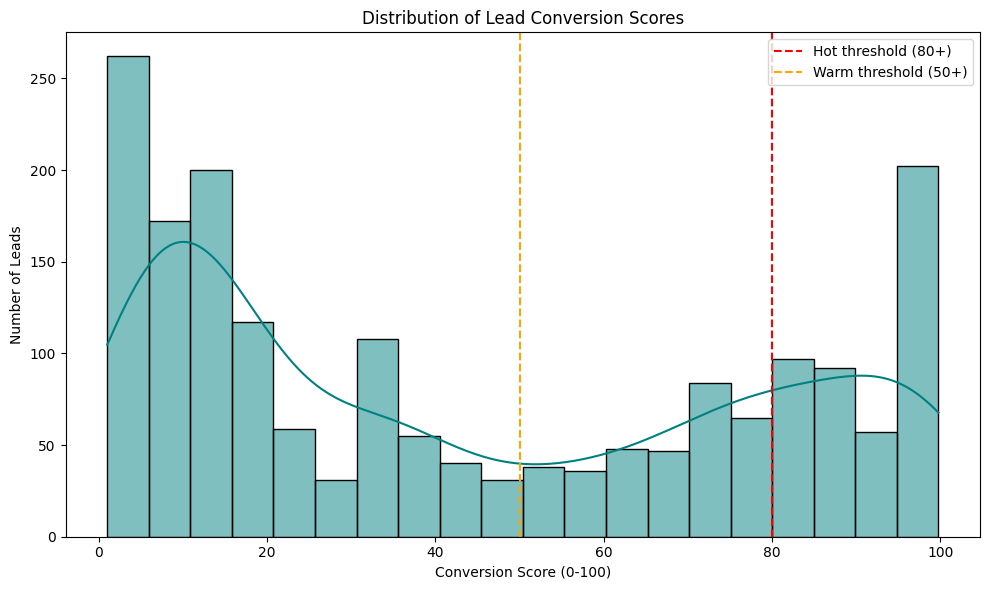

In [48]:
plt.figure(figsize=(10, 6))
sns.histplot(ranked_leads['conversion_score'], bins=20, kde=True, color='teal')
plt.axvline(x=80, color='red',    linestyle='--', label='Hot threshold (80+)')
plt.axvline(x=50, color='orange', linestyle='--', label='Warm threshold (50+)')
plt.title('Distribution of Lead Conversion Scores')
plt.xlabel('Conversion Score (0-100)')
plt.ylabel('Number of Leads')
plt.legend()
plt.tight_layout()

plt.savefig("assets/plot11.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\shikh\AppData\Local\Temp\ipykernel_6608\3347104798.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='actual_converted', y='conversion_score', data=ranked_leads, palette='Set2')


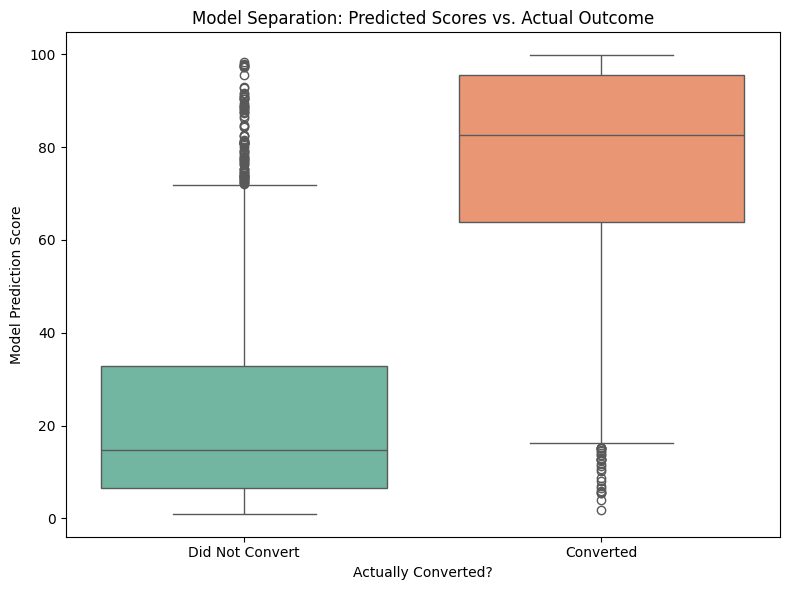

In [49]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='actual_converted', y='conversion_score', data=ranked_leads, palette='Set2')
plt.title('Model Separation: Predicted Scores vs. Actual Outcome')
plt.xlabel('Actually Converted?')
plt.ylabel('Model Prediction Score')
plt.xticks([0, 1], ['Did Not Convert', 'Converted'])
plt.tight_layout()
plt.show()

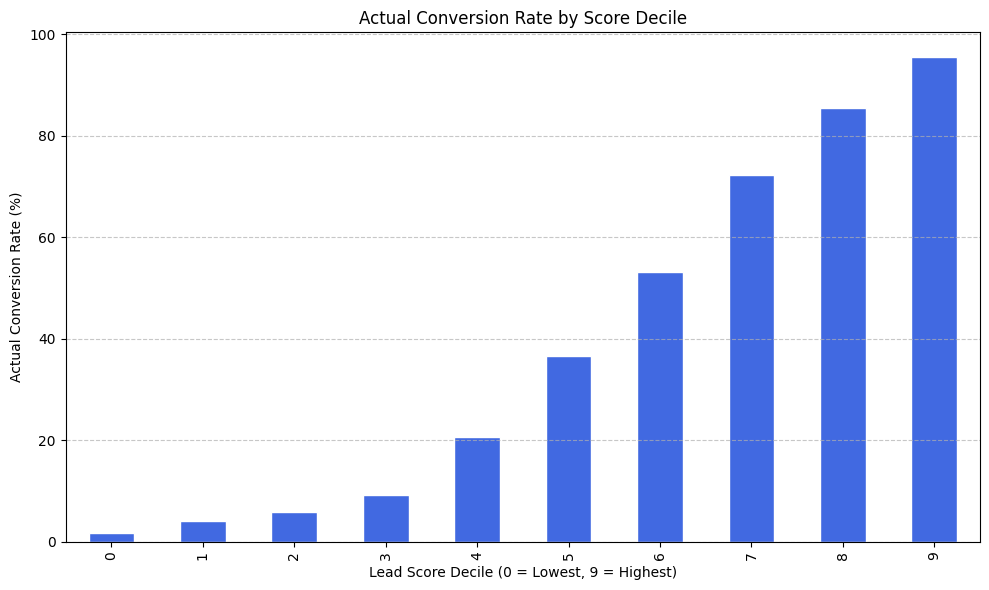

In [50]:
ranked_leads['decile'] = pd.qcut(
    ranked_leads['conversion_score'], 10, labels=False, duplicates='drop'
)
decile_stats = ranked_leads.groupby('decile')['actual_converted'].mean() * 100

plt.figure(figsize=(10, 6))
decile_stats.plot(kind='bar', color='royalblue', edgecolor='white')
plt.title('Actual Conversion Rate by Score Decile')
plt.xlabel('Lead Score Decile (0 = Lowest, 9 = Highest)')
plt.ylabel('Actual Conversion Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 13 · SHAP Explainability

In [51]:
import shap

raw_names = col_trans.get_feature_names_out()
clean_names = [
    n.replace('category__', '').replace('numerical_skew__', '')
     .replace('numerical__', '').replace('bin_col__', '')
     .replace('_', ' ').title()
    for n in raw_names
]
clean_names = [n.replace('What Matters Most To You In Choosing A Course Nan', 'Motivation: Missing') for n in clean_names]
clean_names = [n.replace('What Matters Most To You In Choosing A Course', 'Goal:') for n in clean_names]
clean_names = [n.replace('Total Time Spent On Website', 'Time on Site (Sec)') for n in clean_names]

X_test_shap = pd.DataFrame(X_Test, columns=clean_names)

explainer    = shap.TreeExplainer(model)
shap_values  = explainer(X_test_shap)
print("SHAP values computed.")

SHAP values computed.


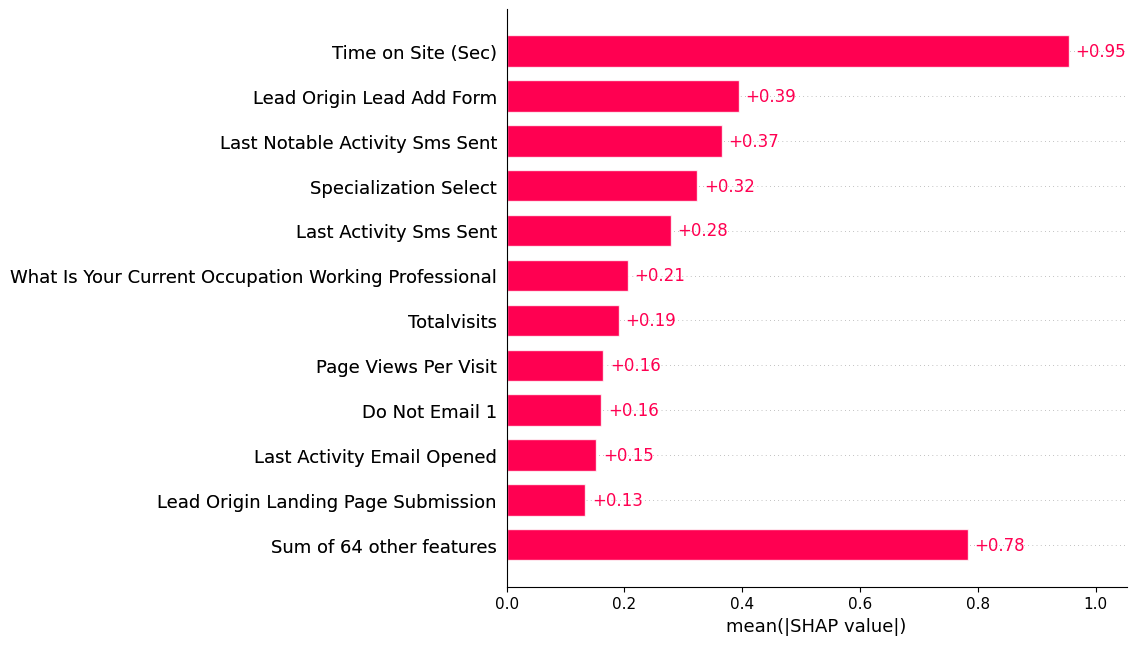

In [52]:
# BUG 13 FIXED: removed orphan plt.figure() calls before SHAP plots.
# shap.plots.bar() and shap.plots.beeswarm() create their own figures
# internally — preceding plt.figure() produces a blank empty figure.

shap.plots.bar(shap_values, max_display=12, show=False)
plt.gcf().savefig("assets/plot12.png", dpi=300, bbox_inches="tight")
plt.show()

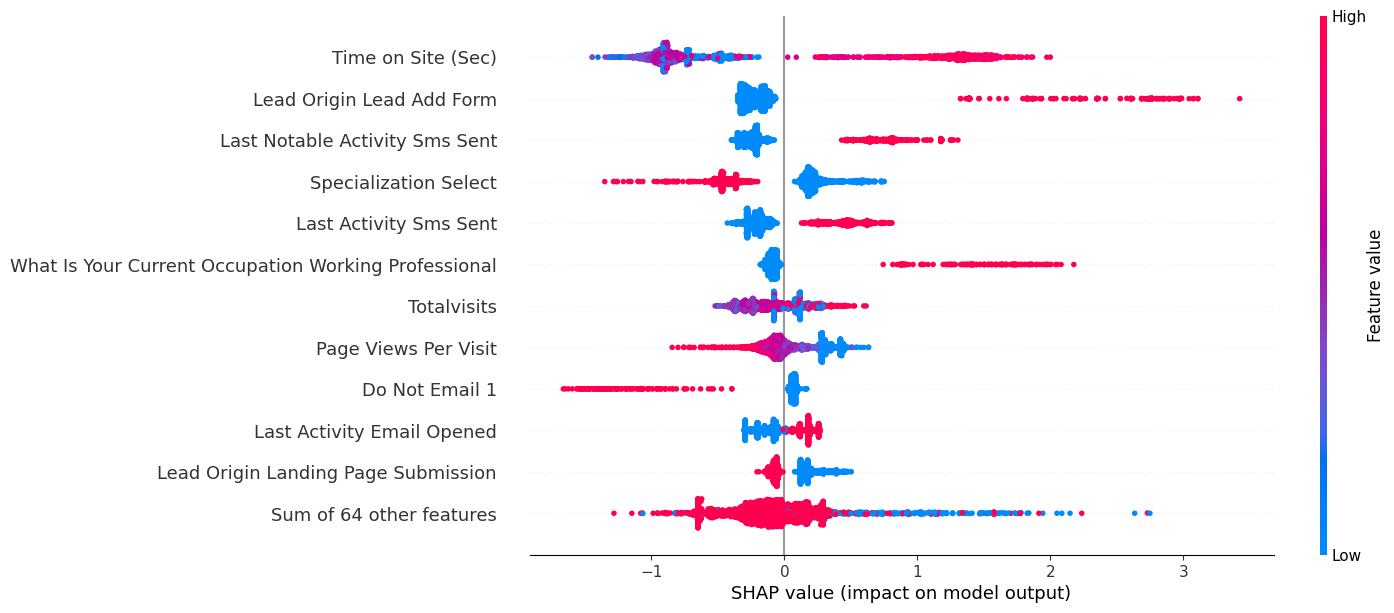

In [53]:
# BUG 13 FIXED (same): no plt.figure() before this call
shap.plots.beeswarm(shap_values, max_display=12, plot_size=(12, 7),show=False)
plt.gcf().savefig("assets/plot13.png", dpi=300, bbox_inches="tight")
plt.show()

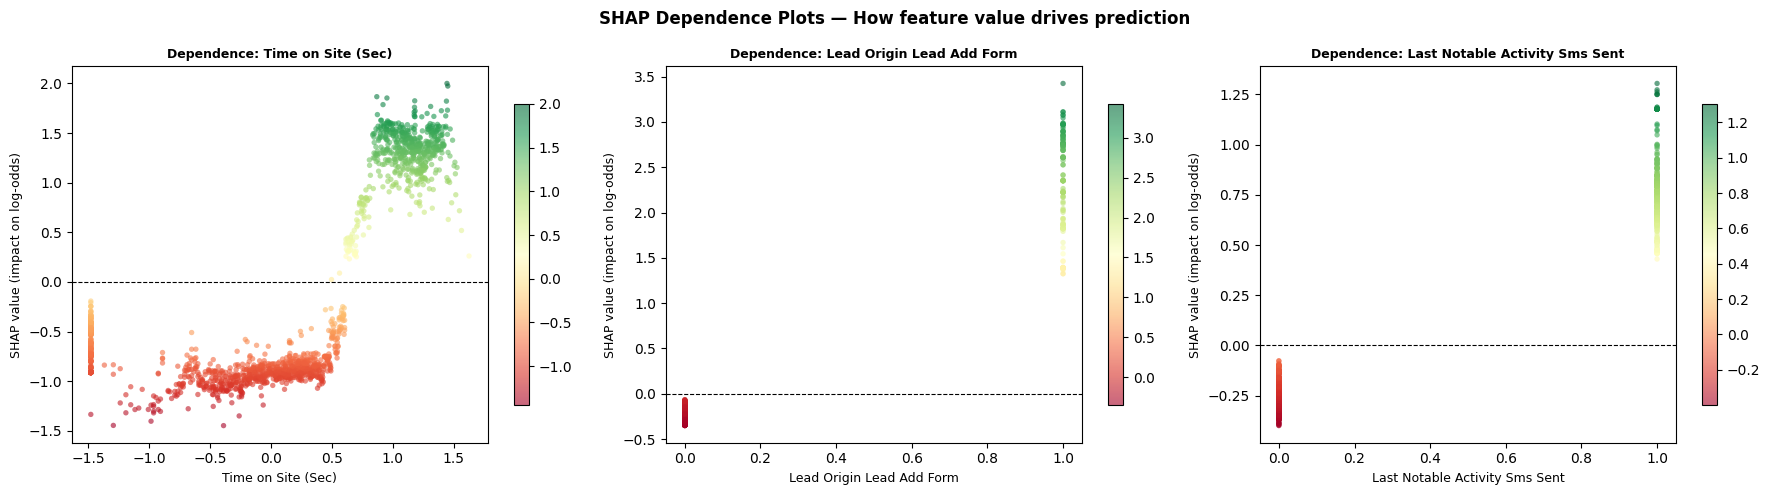

In [54]:
# ★ ADDED — 15.1 SHAP Dependence plots for top 3 features
shap_vals_arr = shap_values.values
top3_features = pd.Series(np.abs(shap_vals_arr).mean(axis=0), 
                          index=clean_names).nlargest(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3_features):
    feat_idx = clean_names.index(feat)
    ax = axes[i]
    sc = ax.scatter(X_test_shap[feat], shap_vals_arr[:, feat_idx],
                    c=shap_vals_arr[:, feat_idx], cmap='RdYlGn', 
                    alpha=0.6, s=15, edgecolors='none')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('SHAP value (impact on log-odds)', fontsize=9)
    ax.set_title(f'Dependence: {feat[:30]}', fontsize=9, fontweight='bold')
    plt.colorbar(sc, ax=ax, shrink=0.8)

plt.suptitle('SHAP Dependence Plots — How feature value drives prediction', 
             fontsize=12, fontweight='bold')
plt.tight_layout()

plt.savefig("assets/plot14.png", dpi=300, bbox_inches="tight")
plt.show()



TOP LEAD (Highest Score) — Score: 99.8 | Actually converted: 1.0


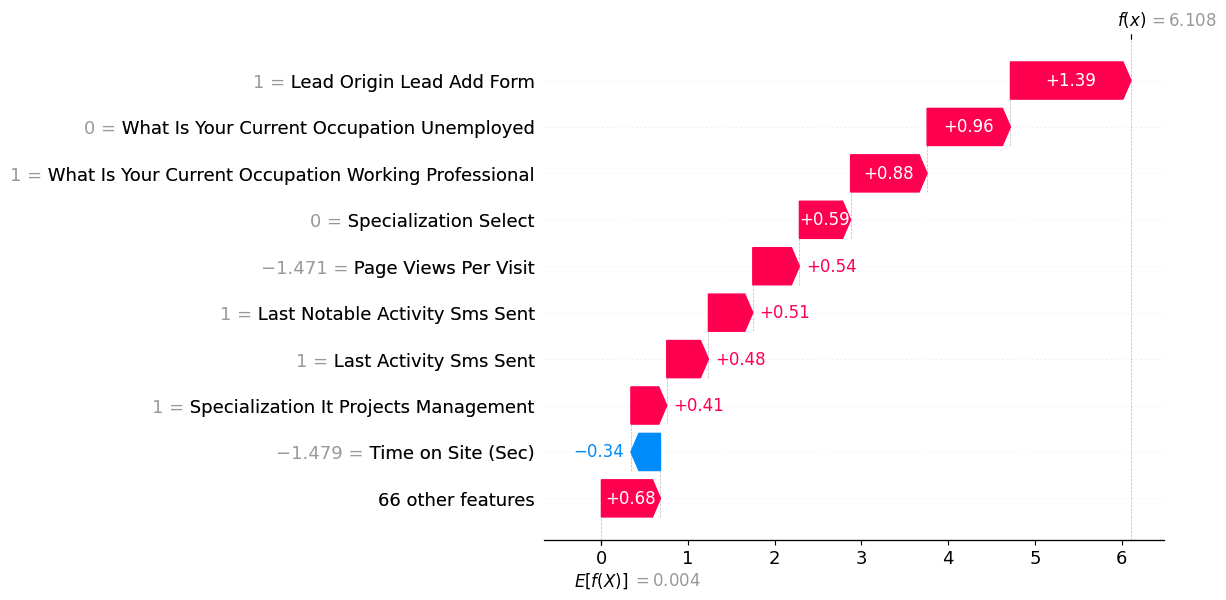


COLD LEAD (Lowest Score) — Score: 1.0 | Actually converted: 0.0


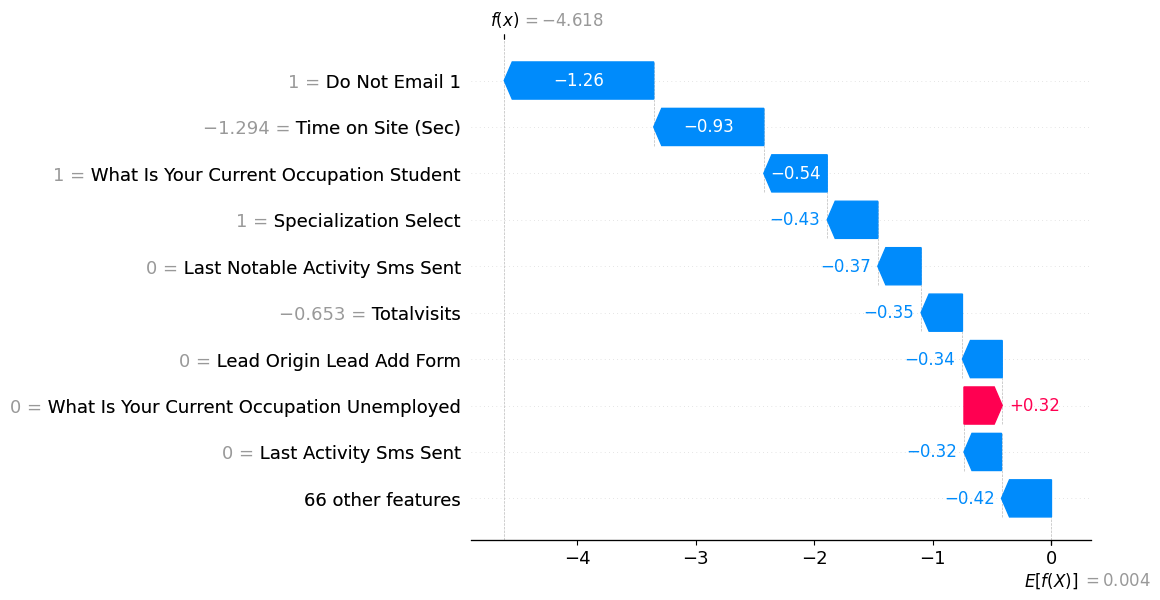


BORDERLINE LEAD (~50 Score) — Score: 50.0 | Actually converted: 0.0


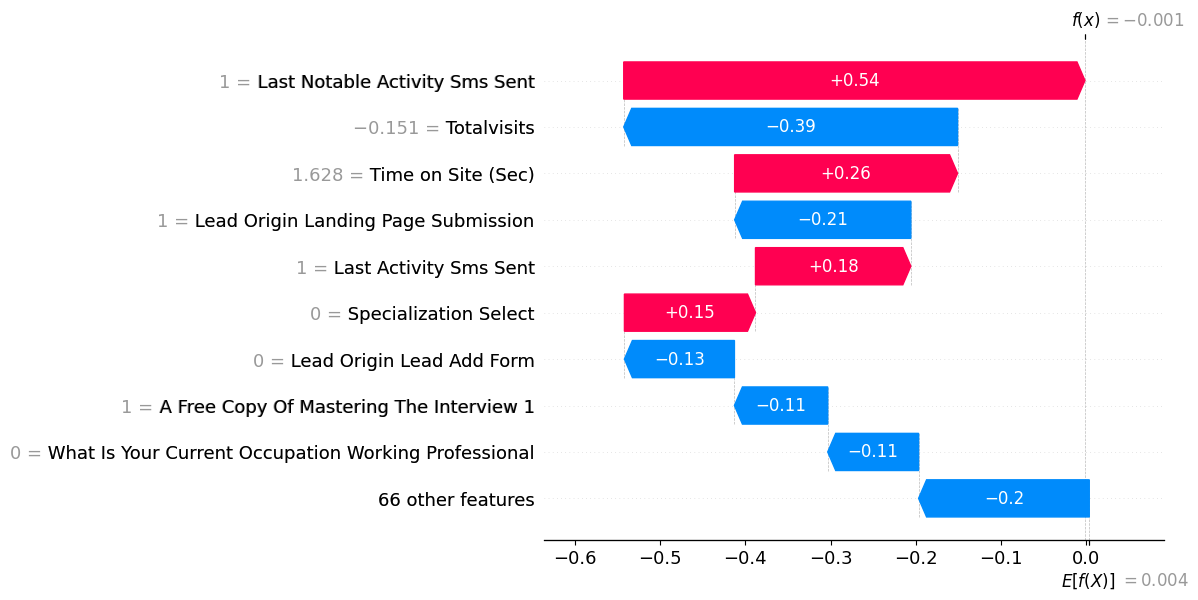

In [ ]:
#  Waterfall plot for a HOT lead, a COLD lead, a borderline lead
# Fixed SHAP index alignment issue

# IMPORTANT:
# ranked_leads must preserve original y_test indices

ranked_leads = pd.DataFrame({
    'test_index': y_test.index,
    'conversion_score': (y_prob * 100).round(2),
    'actual_converted': y_test.values
}).sort_values(
    by='conversion_score',
    ascending=False
).reset_index(drop=True)


def plot_waterfall_for_lead(rank_position, label, color):
    """Show why a specific ranked lead got their score."""
    
    # Get row using POSITIONAL indexing
    row = ranked_leads.iloc[rank_position]
    
    # Original test-set index
    test_index = row['test_index']
    
    # Correct SHAP position inside test set
    test_position = y_test.index.get_loc(test_index)
    
    score = row['conversion_score']
    actual = row['actual_converted']

    print(f"\n{'='*60}")
    print(f"{label} — Score: {score:.1f} | Actually converted: {actual}")
    print(f"{'='*60}")

    shap.plots.waterfall(
        shap_values[test_position],
        max_display=10,
        show=False
    )   
    #saving the image:
    plt.gcf().savefig(
        f"assets/15-{label}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# Top lead (highest score)
plot_waterfall_for_lead(0, 'TOP LEAD (Highest Score)', 'green')

# Bottom lead (lowest score)
plot_waterfall_for_lead(-1, 'COLD LEAD (Lowest Score)', 'red')

# Borderline lead (closest to 50)
borderline_idx = (ranked_leads['conversion_score'] - 50).abs().argmin()

plot_waterfall_for_lead(
    borderline_idx,
    'BORDERLINE LEAD (~50 Score)',
    'orange'
)


## 14 · Post-Encoding Correlation Matrix

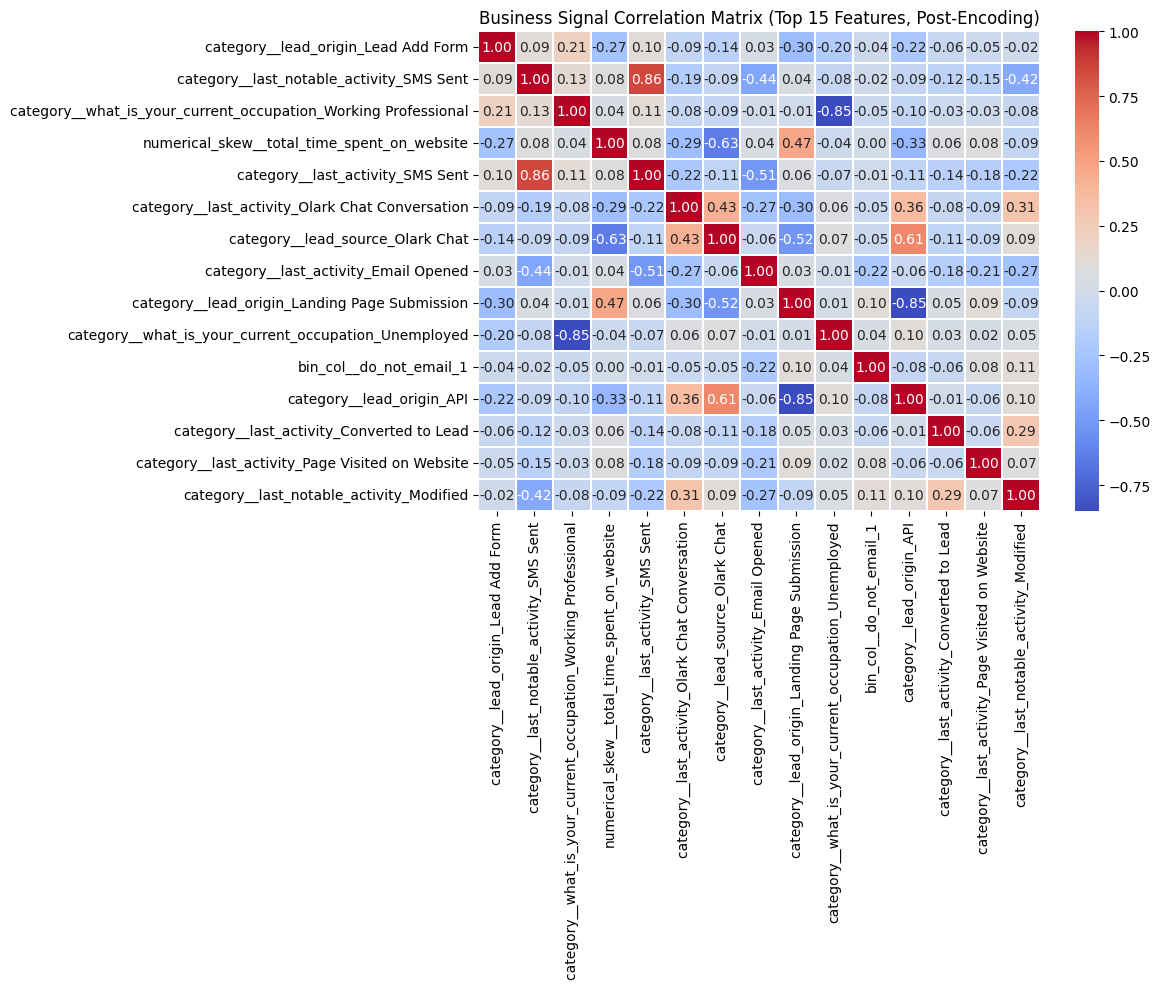

In [56]:
plt.figure(figsize=(12, 10))
correlation_matrix = pd.DataFrame(X_Train, columns=feature_names).corr()
top_corr_features  = feat_importances.nlargest(15).index

sns.heatmap(
    correlation_matrix.loc[top_corr_features, top_corr_features],
    annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.3
)
plt.title('Business Signal Correlation Matrix (Top 15 Features, Post-Encoding)')
plt.tight_layout()

plt.savefig("assets/plot16.png", dpi=300, bbox_inches="tight")
plt.show()

## 15 · Decision Tree Visualisation

e:\python_pi\Lib\site-packages\xgboost\plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


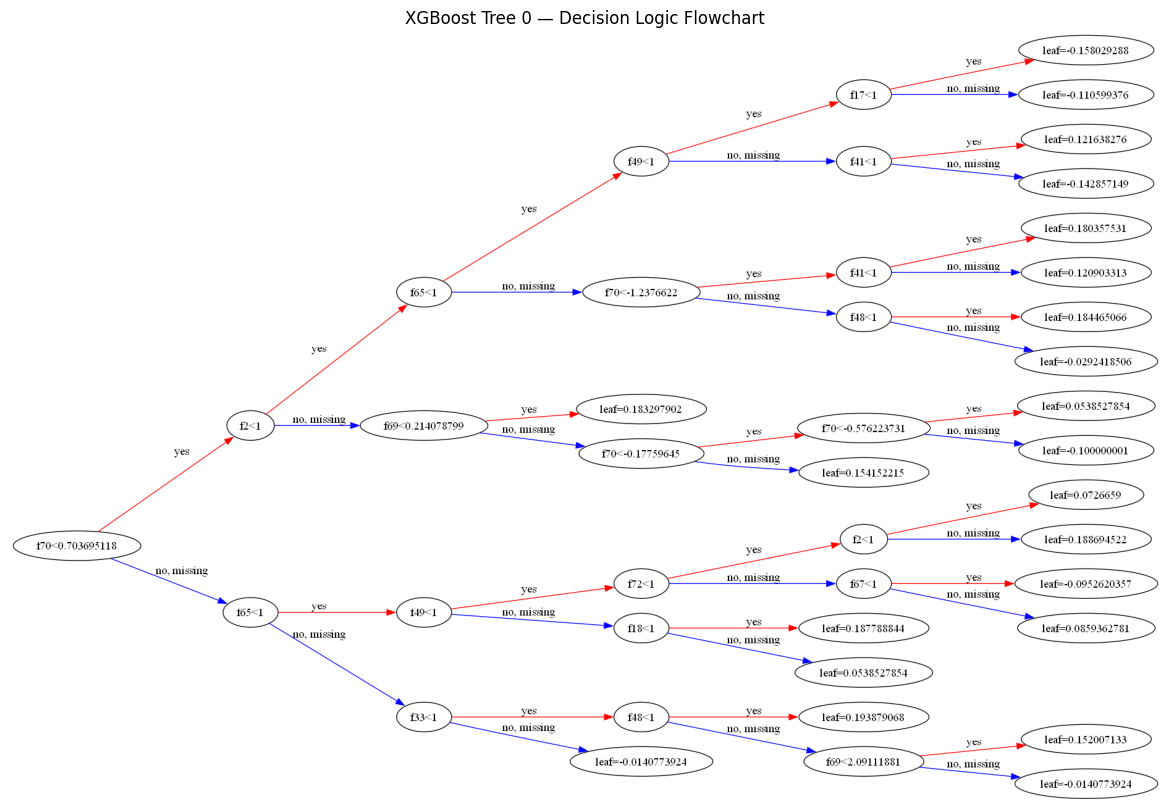

In [57]:
import os, shutil

graphviz_bin = r"C:\Program Files\Graphviz\bin"
if shutil.which('dot') is None and os.path.isdir(graphviz_bin):
    os.environ['PATH'] = graphviz_bin + os.pathsep + os.environ.get('PATH', '')

from xgboost import plot_tree
plot_tree(model, num_trees=0, rankdir='LR')
plt.gcf().set_size_inches(20, 10)
plt.title('XGBoost Tree 0 — Decision Logic Flowchart')
plt.savefig("assets/plot17.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [58]:
# ★ ADDED — Save all artefacts needed for Stage 4 FastAPI endpoint
import pickle
import json

# 1. Save the calibrated model (not raw XGBoost — calibrated probabilities are better)
with open('model.pkl', 'wb') as f:
    pickle.dump(cal_model, f)
print("✓ Saved: model.pkl  (Platt-calibrated XGBoost)")

# 2. Save the ColumnTransformer (needed to preprocess at inference time)
with open('col_trans.pkl', 'wb') as f:
    pickle.dump(col_trans, f)
print("✓ Saved: col_trans.pkl  (preprocessing pipeline)")

# 3. Save exact feature column order (inference must match training exactly)
feature_metadata = {
    'cat_cols': cat_cols_list,
    'num_cols': num_cols,
    'bin_cols': bin_cols,
    'feature_names_out': list(col_trans.get_feature_names_out()),
    'n_features_in': int(X_Train.shape[1])
}
with open('feature_cols.json', 'w') as f:
    json.dump(feature_metadata, f, indent=2)
print("✓ Saved: feature_cols.json  (feature schema)")

# 4. Save threshold + model performance summary
threshold_data = {
    'optimal_threshold': float(OPTIMAL_THRESHOLD),
    'default_threshold': 0.5,
    'auc_roc': float(roc_auc_score(y_test, y_prob)),
    'auc_roc_calibrated': float(roc_auc_score(y_test, y_prob_cal)),
    'brier_score': float(brier_score_loss(y_test, y_prob_cal)),
    'f1_at_optimal': float(f1_score(y_test, (y_prob >= OPTIMAL_THRESHOLD).astype(int))),
    'model_version': 'v1.0',
    'training_rows': int(X_Train.shape[0]),
    'n_features': int(X_Train.shape[1])
}
with open('threshold.json', 'w') as f:
    json.dump(threshold_data, f, indent=2)
print("✓ Saved: threshold.json  (deployment config)")

print()
print("=" * 50)
print("★ PRODUCTION ARTEFACT SUMMARY")
print("=" * 50)
for k, v in threshold_data.items():
    print(f"  {k:<30} {v}")
print()
print("→ Load these in Stage 4 (api.py):")
print("  model     = pickle.load(open('model.pkl', 'rb'))")
print("  col_trans = pickle.load(open('col_trans.pkl', 'rb'))")
print("  config    = json.load(open('threshold.json'))")


✓ Saved: model.pkl  (Platt-calibrated XGBoost)
✓ Saved: col_trans.pkl  (preprocessing pipeline)
✓ Saved: feature_cols.json  (feature schema)
✓ Saved: threshold.json  (deployment config)

★ PRODUCTION ARTEFACT SUMMARY
  optimal_threshold              0.49493670886075947
  default_threshold              0.5
  auc_roc                        0.9045949757272467
  auc_roc_calibrated             0.9045949757272467
  brier_score                    0.12087226373819418
  f1_at_optimal                  0.7929634641407307
  model_version                  v1.0
  training_rows                  7363
  n_features                     75

→ Load these in Stage 4 (api.py):
  model     = pickle.load(open('model.pkl', 'rb'))
  col_trans = pickle.load(open('col_trans.pkl', 'rb'))
  config    = json.load(open('threshold.json'))
